# BERT Multi-Task ABSA — Aspect Category + Sentiment
Kiến trúc: `Input → BERT (shared encoder) → Head 1: aspect detection → Head 2: sentiment classification`

- **Head 1**: multi-label binary classification — câu thuộc category nào?
- **Head 2**: per-category sentiment (POS / NEG / NEU) — train song song, không tuần tự
- Data: SemEval 2014 XML format


In [10]:
!pip install transformers tensorboardX tqdm -q

## 1. Config
Toàn bộ tham số dự án — chỉ chỉnh tại đây.

In [11]:
import os
import numpy as np

# ── Môi trường ────────────────────────────────────────────────────────────
ON_KAGGLE   = os.path.exists('/kaggle/working')
WORKING_DIR = '/kaggle/working' if ON_KAGGLE else os.getcwd()
print('Environment:', 'Kaggle' if ON_KAGGLE else 'Local')

# ── Model ─────────────────────────────────────────────────────────────────
MODEL_NAME    = 'vinai/phobert-base'   # PhoBERT cho tiếng Việt
DO_LOWER_CASE = False                  # PhoBERT case-sensitive

# ── Data ──────────────────────────────────────────────────────────────────
if ON_KAGGLE:
    CSV_PATH   = '/kaggle/input/datasets/conanwinner1/vku-feedback/v1.csv'
    OUTPUT_DIR = f'{WORKING_DIR}/bert-multitask-acsa'
else:
    CSV_PATH   = os.path.join(os.path.dirname(os.getcwd()), 'Final', 'data', 'v1.csv')
    OUTPUT_DIR = os.path.join(WORKING_DIR, 'bert-multitask-acsa')

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Aspect Categories (từ v1.csv aspect_label 0-14) ──────────────────────
ASPECT_CATEGORIES = [
    'LECTURER#Teaching_Skill',    # 0
    'LECTURER#Knowledge',          # 1
    'LECTURER#Experience',         # 2
    'LECTURER#Behavior',           # 3
    'LECTURER#Support',            # 4
    'COURSE#Curriculum',           # 5
    'COURSE#Materials',            # 6
    'COURSE#Workload',             # 7
    'COURSE#Assignments',          # 8
    'ASSESSMENT#Grading',          # 9
    'ASSESSMENT#Exams',            # 10
    'FACILITIES#Classroom',        # 11
    'FACILITIES#Platforms',        # 12
    'OTHERS#General',              # 13
    'OTHERS#Recommendation',       # 14
]
NUM_ASPECTS = len(ASPECT_CATEGORIES)
ASPECT2ID   = {a: i for i, a in enumerate(ASPECT_CATEGORIES)}
ID2ASPECT   = {i: a for i, a in enumerate(ASPECT_CATEGORIES)}

# ── Sentiment (từ v1.csv sentiment_label) ────────────────────────────────
POLARITIES     = ['negative', 'neutral', 'positive']  # 0, 1, 2
NUM_POLARITIES = len(POLARITIES)
POL2ID         = {p: i for i, p in enumerate(POLARITIES)}
ID2POL         = {i: p for i, p in enumerate(POLARITIES)}
IGNORE_INDEX   = -100

# ── Training ──────────────────────────────────────────────────────────────
SEED             = 42
MAX_EPOCHS       = 10
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE  = 32
LEARNING_RATE    = 2e-5
WARMUP_RATIO     = 0.1
MAX_SEQ_LENGTH   = 128
WEIGHT_DECAY     = 0.01

# ── Multi-task loss weights ───────────────────────────────────────────────
ALPHA = 1.0   # aspect detection (BCE)
BETA  = 1.0   # sentiment classify (CE)

# ── Logging ───────────────────────────────────────────────────────────────
LOG_STEPS  = 50
SAVE_STEPS = 200

print(f'CSV       : {CSV_PATH}')
print(f'Model     : {MODEL_NAME}')
print(f'Categories: {NUM_ASPECTS}')
print(f'Output    : {OUTPUT_DIR}')


Environment: Kaggle
CSV       : /kaggle/input/datasets/conanwinner1/vku-feedback/v1.csv
Model     : vinai/phobert-base
Categories: 15
Output    : /kaggle/working/bert-multitask-acsa


## 2. Kiểm tra GPU

In [12]:
import torch
print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpu  = torch.cuda.device_count()


PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


## 3. Data — Convert CSV → Category CSV

In [13]:
import pandas as pd
from collections import Counter

def load_acsa_data(csv_path):
    """
    Load v1.csv và group theo id (sentence) → mỗi sample có:
      - text
      - aspect_labels    : (NUM_ASPECTS,) float multi-hot
      - sentiment_labels : (NUM_ASPECTS,) int, IGNORE_INDEX nếu absent
    """
    df = pd.read_csv(csv_path)
    
    # Bỏ conflict nếu có
    df = df[df['sentiment'] != 'conflict'].copy()
    
    samples = []
    for sent_id, group in df.groupby('id'):
        text = group.iloc[0]['text']
        
        aspect_labels    = np.zeros(NUM_ASPECTS, dtype=np.float32)
        sentiment_labels = np.full(NUM_ASPECTS, IGNORE_INDEX, dtype=np.int64)
        
        for _, row in group.iterrows():
            asp_idx = int(row['aspect_label'])
            sen_idx = int(row['sentiment_label'])
            
            if 0 <= asp_idx < NUM_ASPECTS:
                aspect_labels[asp_idx] = 1.0
                # Nếu trùng category, lấy sentiment đầu tiên
                if sentiment_labels[asp_idx] == IGNORE_INDEX:
                    sentiment_labels[asp_idx] = sen_idx
        
        samples.append({
            'id':               sent_id,
            'text':             text,
            'aspect_labels':    aspect_labels,
            'sentiment_labels': sentiment_labels,
        })
    
    return samples


def print_stats(samples, split_name):
    print(f'=====================================================')
    print(f'  {split_name}: {len(samples)} sentences')
    print(f'=====================================================')
    
    aspect_counts = np.zeros(NUM_ASPECTS)
    pol_counts    = Counter()
    
    for s in samples:
        aspect_counts += s['aspect_labels']
        for i, v in enumerate(s['sentiment_labels']):
            if v != IGNORE_INDEX:
                pol_counts[ID2POL[v]] += 1
    
    print('  Aspect distribution:')
    max_cnt = aspect_counts.max()
    for i, cat in enumerate(ASPECT_CATEGORIES):
        cnt = int(aspect_counts[i])
        bar = '█' * int(30 * cnt / (max_cnt or 1))
        print(f'    {i:2d}. {cat:<30s} {cnt:4d}  {bar}')
    
    print('\n  Polarity distribution:')
    total_pol = sum(pol_counts.values())
    for pol in POLARITIES:
        cnt = pol_counts[pol]
        bar = '█' * int(30 * cnt / (total_pol or 1))
        print(f'    {pol:<12s} {cnt:4d} ({100*cnt/(total_pol or 1):.1f}%)  {bar}')


all_samples = load_acsa_data(CSV_PATH)
print(f'Loaded {len(all_samples)} unique sentences from {CSV_PATH}')

# Split 70 / 15 / 15
from sklearn.model_selection import train_test_split
train_s, tmp_s  = train_test_split(all_samples, test_size=0.3,  random_state=SEED)
dev_s,   test_s = train_test_split(tmp_s,       test_size=0.5, random_state=SEED)

print_stats(train_s, 'Train')
print_stats(dev_s,   'Dev')
print_stats(test_s,  'Test')


Loaded 1694 unique sentences from /kaggle/input/datasets/conanwinner1/vku-feedback/v1.csv
  Train: 1185 sentences
  Aspect distribution:
     0. LECTURER#Teaching_Skill         235  █████████████████████████████
     1. LECTURER#Knowledge               59  ███████
     2. LECTURER#Experience              37  ████
     3. LECTURER#Behavior               242  ██████████████████████████████
     4. LECTURER#Support                 78  █████████
     5. COURSE#Curriculum               181  ██████████████████████
     6. COURSE#Materials                 26  ███
     7. COURSE#Workload                  15  █
     8. COURSE#Assignments               25  ███
     9. ASSESSMENT#Grading               14  █
    10. ASSESSMENT#Exams                 14  █
    11. FACILITIES#Classroom            207  █████████████████████████
    12. FACILITIES#Platforms             18  ██
    13. OTHERS#General                  117  ██████████████
    14. OTHERS#Recommendation            21  ██

  Polarity distribu

## 4. Dataset & DataLoader — từ Category CSV

In [14]:
import torch
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class ACSADataset(Dataset):
    def __init__(self, samples, tokenizer, max_len):
        self.samples   = samples
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s   = self.samples[idx]
        enc = self.tokenizer(
            s['text'],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':        enc['input_ids'].squeeze(0),
            'attention_mask':   enc['attention_mask'].squeeze(0),
            'aspect_labels':    torch.tensor(s['aspect_labels'],    dtype=torch.float),
            'sentiment_labels': torch.tensor(s['sentiment_labels'], dtype=torch.long),
        }


train_dataset = ACSADataset(train_s, tokenizer, MAX_SEQ_LENGTH)
dev_dataset   = ACSADataset(dev_s,   tokenizer, MAX_SEQ_LENGTH)
test_dataset  = ACSADataset(test_s,  tokenizer, MAX_SEQ_LENGTH)

train_loader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset),     batch_size=TRAIN_BATCH_SIZE)
dev_loader   = DataLoader(dev_dataset,   sampler=SequentialSampler(dev_dataset),   batch_size=EVAL_BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  sampler=SequentialSampler(test_dataset),  batch_size=EVAL_BATCH_SIZE)

print(f'Train: {len(train_dataset)} | Dev: {len(dev_dataset)} | Test: {len(test_dataset)} sentences')


Train: 1185 | Dev: 254 | Test: 255 sentences


In [15]:
print(train_s[:10])
print(dev_s[:10])
print(test_s[:10])

[{'id': 'vsfc_00756', 'text': 'Thầy không có sự hướng dẫn và hỗ trợ sinh viên trong việc học tập, chỉ bắt họ tuân thủ các quy định.', 'aspect_labels': array([0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32), 'sentiment_labels': array([-100, -100, -100,    0,    0, -100, -100, -100, -100, -100, -100,
       -100, -100, -100, -100])}, {'id': 'vsfc_00086', 'text': 'Bạn ấy là người có khả năng làm việc độc lập và tự tin.', 'aspect_labels': array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32), 'sentiment_labels': array([-100, -100, -100,    2, -100, -100, -100, -100, -100, -100, -100,
       -100, -100, -100, -100])}, {'id': 'vsfc_00925', 'text': 'Giảng viên không cung cấp đủ thông tin để tôi có thể hiểu bài.', 'aspect_labels': array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32), 'sentiment_labels': array([   0, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
       -100, -1

## 5. Model — BertMultiTaskABSA

In [16]:
import torch.nn as nn
from transformers import AutoModel
import numpy as np

# Tính pos_weight từ train set trước khi khởi tạo model
all_asp    = np.array([s['aspect_labels'] for s in train_s])  # (N, 15)
pos_counts = all_asp.sum(axis=0)
neg_counts = len(all_asp) - pos_counts
pw         = torch.tensor(neg_counts / (pos_counts + 1e-8), dtype=torch.float)
print('pos_weight:', pw.numpy().round(1))


class BertMultiTaskABSA(nn.Module):
    def __init__(self, model_name, num_aspects, num_polarities, pos_weight, dropout=0.1):
        super().__init__()
        self.encoder        = AutoModel.from_pretrained(model_name)
        hidden              = self.encoder.config.hidden_size
        self.dropout        = nn.Dropout(dropout)
        self.aspect_head    = nn.Linear(hidden, num_aspects)
        self.sentiment_head = nn.Linear(hidden, num_aspects * num_polarities)
        self.num_aspects    = num_aspects
        self.num_polarities = num_polarities
        # register_buffer → tự động move sang đúng device khi .to(device) hoặc DataParallel
        self.register_buffer('pos_weight', pos_weight)

    def forward(self, input_ids, attention_mask,
                aspect_labels=None, sentiment_labels=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled  = self.dropout(outputs.pooler_output)

        asp_logits  = self.aspect_head(pooled)
        sent_logits = self.sentiment_head(pooled).view(-1, self.num_aspects, self.num_polarities)

        loss = None
        if aspect_labels is not None and sentiment_labels is not None:
            loss_aspect = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)(asp_logits, aspect_labels)
            loss_sent   = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)(
                sent_logits.view(-1, self.num_polarities),
                sentiment_labels.view(-1),
            )
            loss = ALPHA * loss_aspect + BETA * loss_sent

        return loss, asp_logits, sent_logits


import sys, os
if not hasattr(sys.modules['__main__'], '__file__'):
    dummy = os.path.abspath('dummy_fix.py')
    open(dummy, 'w').close()
    sys.modules['__main__'].__file__ = dummy

model = BertMultiTaskABSA(MODEL_NAME, NUM_ASPECTS, NUM_POLARITIES, pos_weight=pw)
model.to(device)
if n_gpu > 1:
    model = nn.DataParallel(model)

print(f'✓ Model loaded | Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


pos_weight: [ 4.  19.1 31.   3.9 14.2  5.5 44.6 78.  46.4 83.6 83.6  4.7 64.8  9.1
 55.4]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model loaded | Params: 135,044,412


## 6. Training

In [17]:
from sklearn.metrics import f1_score, classification_report
import numpy as np

def evaluate_model(model, loader):
    model.eval()
    total_loss   = 0.0
    all_asp_gold, all_asp_pred = [], []
    all_sen_gold, all_sen_pred = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating', leave=False):
            input_ids        = batch['input_ids'].to(device)
            attention_mask   = batch['attention_mask'].to(device)
            aspect_labels    = batch['aspect_labels'].to(device)
            sentiment_labels = batch['sentiment_labels'].to(device)

            loss, asp_logits, sent_logits = model(
                input_ids, attention_mask,
                aspect_labels, sentiment_labels)
            if n_gpu > 1: loss = loss.mean()
            total_loss += loss.item()

            # Aspect: threshold 0.5
            asp_pred = (torch.sigmoid(asp_logits) > 0.5).cpu().numpy().astype(int)
            asp_gold = aspect_labels.cpu().numpy().astype(int)
            all_asp_gold.append(asp_gold)
            all_asp_pred.append(asp_pred)

            # Sentiment: argmax, chỉ tính ở vị trí present
            sent_pred = torch.argmax(sent_logits, dim=-1).cpu().numpy()  # (B, A)
            sent_gold = sentiment_labels.cpu().numpy()                    # (B, A)
            mask      = sent_gold != IGNORE_INDEX
            all_sen_gold.extend(sent_gold[mask].tolist())
            all_sen_pred.extend(sent_pred[mask].tolist())

    all_asp_gold = np.vstack(all_asp_gold)
    all_asp_pred = np.vstack(all_asp_pred)

    aspect_f1 = f1_score(all_asp_gold, all_asp_pred, average='micro', zero_division=0)
    sent_f1   = f1_score(all_sen_gold, all_sen_pred, average='macro', zero_division=0)

    return {
        'loss':      total_loss / len(loader),
        'aspect_f1': aspect_f1,
        'sent_f1':   sent_f1,
        'asp_gold':  all_asp_gold,
        'asp_pred':  all_asp_pred,
        'sen_gold':  all_sen_gold,
        'sen_pred':  all_sen_pred,
    }


In [18]:
import random
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from tqdm.notebook import tqdm, trange
from tensorboardX import SummaryWriter

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

set_seed(SEED)

t_total       = len(train_loader) * MAX_EPOCHS
warmup_steps  = int(t_total * WARMUP_RATIO)

no_decay = ['bias', 'LayerNorm.weight']
optimizer = AdamW([
    {'params': [p for n,p in model.named_parameters() if not any(nd in n for nd in no_decay)], 'weight_decay': WEIGHT_DECAY},
    {'params': [p for n,p in model.named_parameters() if     any(nd in n for nd in no_decay)], 'weight_decay': 0.0},
], lr=LEARNING_RATE, eps=1e-8)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, t_total)

tb_writer   = SummaryWriter(log_dir=OUTPUT_DIR)
global_step = 0
history     = {'epoch': [], 'train_loss': [], 'val_loss': [], 'val_f1': []}

for epoch in trange(MAX_EPOCHS, desc='Epoch'):
    model.train()
    epoch_loss, epoch_steps = 0.0, 0

    for batch in tqdm(train_loader, desc=f'Train E{epoch+1}', leave=False):
        input_ids        = batch['input_ids'].to(device)
        attention_mask   = batch['attention_mask'].to(device)
        aspect_labels    = batch['aspect_labels'].to(device)
        sentiment_labels = batch['sentiment_labels'].to(device)

        loss, _, _ = model(input_ids, attention_mask,
                           aspect_labels, sentiment_labels)
        if n_gpu > 1: loss = loss.mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step(); model.zero_grad()

        epoch_loss  += loss.item()
        epoch_steps += 1
        global_step += 1

        if global_step % LOG_STEPS == 0:
            tb_writer.add_scalar('train_loss', loss.item(), global_step)
            tb_writer.add_scalar('lr', scheduler.get_last_lr()[0], global_step)

        if global_step % SAVE_STEPS == 0:
            ckpt = os.path.join(OUTPUT_DIR, f'checkpoint-{global_step}')
            os.makedirs(ckpt, exist_ok=True)
            m = model.module if hasattr(model, 'module') else model
            torch.save(m.state_dict(), os.path.join(ckpt, 'model.pt'))

    # ── Eval cuối epoch ──────────────────────────────────────────────────
    val_metrics = evaluate_model(model, dev_loader)
    avg_train   = epoch_loss / epoch_steps

    history['epoch'].append(epoch + 1)
    history['train_loss'].append(avg_train)
    history['val_loss'].append(val_metrics['loss'])
    history['val_f1'].append(val_metrics['aspect_f1'])

    tb_writer.add_scalar('val_loss',     val_metrics['loss'],      global_step)
    tb_writer.add_scalar('val_aspect_f1', val_metrics['aspect_f1'], global_step)
    tb_writer.add_scalar('val_sent_f1',  val_metrics['sent_f1'],   global_step)

    print(f"[Epoch {epoch+1}] train_loss={avg_train:.4f} | "
          f"val_loss={val_metrics['loss']:.4f} | "
          f"aspect_f1={val_metrics['aspect_f1']:.4f} | "
          f"sent_f1={val_metrics['sent_f1']:.4f}")

tb_writer.close()
m = model.module if hasattr(model, 'module') else model
torch.save(m.state_dict(), os.path.join(OUTPUT_DIR, 'model_final.pt'))
print(f'\n✓ Training done. Saved to {OUTPUT_DIR}')


Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Train E1:   0%|          | 0/75 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

[Epoch 1] train_loss=2.2597 | val_loss=2.0958 | aspect_f1=0.1156 | sent_f1=0.6194


...

[Epoch 9] train_loss=1.0411 | val_loss=1.1520 | aspect_f1=0.3014 | sent_f1=0.9247


Train E10:   0%|          | 0/75 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

[Epoch 10] train_loss=1.0030 | val_loss=1.1517 | aspect_f1=0.3082 | sent_f1=0.9086

✓ Training done. Saved to /kaggle/working/bert-multitask-acsa


## 7. Evaluation

In [19]:


print('=== Dev ===')
dev_metrics  = evaluate_model(model, dev_loader)
print(f"aspect_f1={dev_metrics['aspect_f1']:.4f} | sent_f1={dev_metrics['sent_f1']:.4f}")

print('\n=== Test ===')
test_metrics = evaluate_model(model, test_loader)
print(f"aspect_f1={test_metrics['aspect_f1']:.4f} | sent_f1={test_metrics['sent_f1']:.4f}")

# Per-category sentiment report
print('\nPer-class Sentiment (Test):')
print(classification_report(
    test_metrics['sen_gold'], test_metrics['sen_pred'],
    target_names=POLARITIES, zero_division=0))


=== Dev ===


Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


aspect_f1=0.3082 | sent_f1=0.9086

=== Test ===


Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


aspect_f1=0.3099 | sent_f1=0.8568

Per-class Sentiment (Test):
              precision    recall  f1-score   support

    negative       0.96      0.97      0.96        88
     neutral       0.67      0.57      0.62         7
    positive       0.99      0.99      0.99       182

    accuracy                           0.97       277
   macro avg       0.87      0.84      0.86       277
weighted avg       0.97      0.97      0.97       277



## 8. Visualization

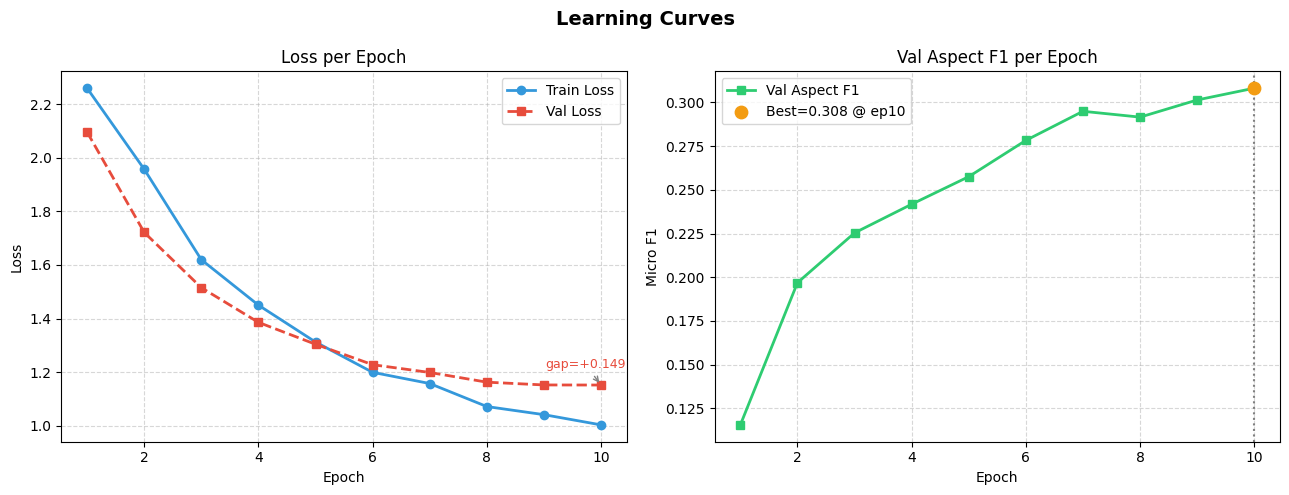

⚠️  Underfit: best_f1=0.308 — thử tăng MAX_EPOCHS hoặc giảm LR.

Metrics summary:
Split  aspect_f1  sent_f1   loss
  Dev     0.3082   0.9086 1.1517
 Test     0.3099   0.8568 1.1161


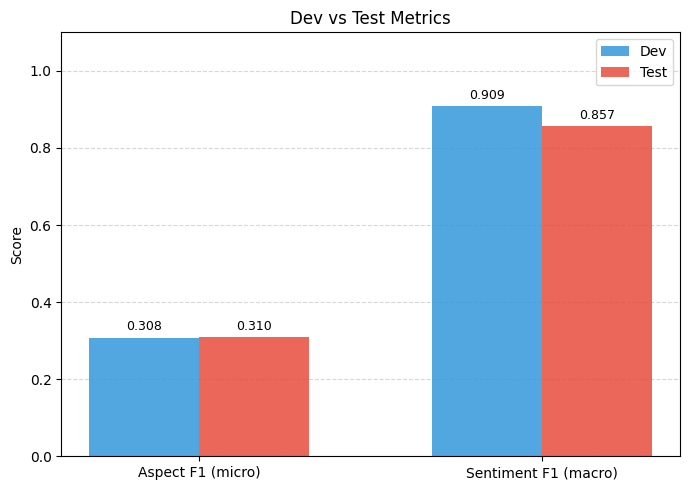

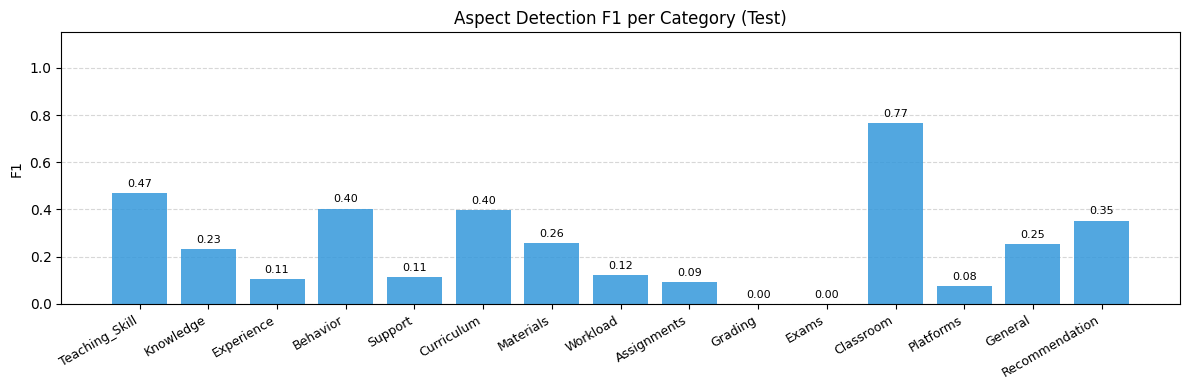

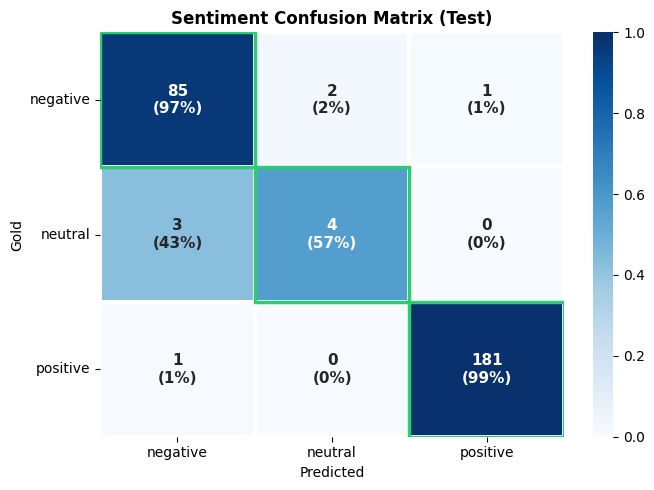


Per-class Sentiment (Test):
              precision    recall  f1-score   support

    negative       0.96      0.97      0.96        88
     neutral       0.67      0.57      0.62         7
    positive       0.99      0.99      0.99       182

    accuracy                           0.97       277
   macro avg       0.87      0.84      0.86       277
weighted avg       0.97      0.97      0.97       277



In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, f1_score as sk_f1

# ── 1. Learning curves (overfit / underfit) ───────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Learning Curves', fontsize=14, fontweight='bold')

epochs = history['epoch']
ax1.plot(epochs, history['train_loss'], 'o-',  color='#3498db', label='Train Loss', lw=2)
ax1.plot(epochs, history['val_loss'],   's--', color='#e74c3c', label='Val Loss',   lw=2)
gap = history['val_loss'][-1] - history['train_loss'][-1]
ax1.annotate(f'gap={gap:+.3f}',
             xy=(epochs[-1], history['val_loss'][-1]),
             xytext=(-40, 12), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='#e74c3c')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss per Epoch')
ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.5); ax1.set_axisbelow(True)

best_epoch = epochs[history['val_f1'].index(max(history['val_f1']))]
best_f1    = max(history['val_f1'])
ax2.plot(epochs, history['val_f1'], 's-', color='#2ecc71', lw=2, label='Val Aspect F1')
ax2.axvline(best_epoch, color='gray', linestyle=':', lw=1.5)
ax2.scatter([best_epoch], [best_f1], color='#f39c12', zorder=5, s=80,
            label=f'Best={best_f1:.3f} @ ep{best_epoch}')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Micro F1'); ax2.set_title('Val Aspect F1 per Epoch')
ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.5); ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

if gap > 0.3:
    print(f"⚠️  Overfit: gap={gap:.3f} — thử tăng dropout hoặc giảm MAX_EPOCHS.")
elif best_f1 < 0.5:
    print(f"⚠️  Underfit: best_f1={best_f1:.3f} — thử tăng MAX_EPOCHS hoặc giảm LR.")
else:
    print(f"✓  Fit tốt: gap={gap:.3f}, best aspect_f1={best_f1:.3f} @ epoch {best_epoch}.")

# ── 2. Dev vs Test metrics bar chart ─────────────────────────────────────
metric_keys = ['aspect_f1', 'sent_f1', 'loss']
summary = pd.DataFrame([
    {'Split': 'Dev',  **{k: round(dev_metrics[k],  4) for k in metric_keys}},
    {'Split': 'Test', **{k: round(test_metrics[k], 4) for k in metric_keys}},
])
print('\nMetrics summary:')
print(summary.to_string(index=False))

plot_keys = ['aspect_f1', 'sent_f1']
x      = np.arange(len(plot_keys))
width  = 0.32
fig, ax = plt.subplots(figsize=(7, 5))
for i, (split, metrics) in enumerate([('Dev', dev_metrics), ('Test', test_metrics)]):
    scores = [metrics[k] for k in plot_keys]
    bars   = ax.bar(x + (i - 0.5) * width, scores, width,
                    label=split, color=['#3498db','#e74c3c'][i], alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', fontsize=9, padding=3)
ax.set_xticks(x); ax.set_xticklabels(['Aspect F1 (micro)', 'Sentiment F1 (macro)'], fontsize=10)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Dev vs Test Metrics')
ax.legend(); ax.yaxis.grid(True, linestyle='--', alpha=0.5); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

# ── 3. Per-category Aspect F1 (Test) ─────────────────────────────────────
per_cat_f1 = [
    sk_f1(test_metrics['asp_gold'][:, i], test_metrics['asp_pred'][:, i], zero_division=0)
    for i in range(NUM_ASPECTS)
]
short_labels = [c.split('#')[1] for c in ASPECT_CATEGORIES]  # rút gọn cho dễ đọc

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(short_labels, per_cat_f1, color='#3498db', alpha=0.85)
ax.bar_label(bars, fmt='%.2f', fontsize=8, padding=3)
ax.set_ylim(0, 1.15); ax.set_ylabel('F1')
ax.set_title('Aspect Detection F1 per Category (Test)')
ax.yaxis.grid(True, linestyle='--', alpha=0.5); ax.set_axisbelow(True)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout(); plt.show()

# ── 4. Sentiment confusion matrix (Test) ─────────────────────────────────
cm      = confusion_matrix(test_metrics['sen_gold'], test_metrics['sen_pred'],
                           labels=list(range(NUM_POLARITIES)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
annots  = np.array([[f'{cm[i,j]}\n({cm_norm[i,j]:.0%})' for j in range(NUM_POLARITIES)]
                    for i in range(NUM_POLARITIES)])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_norm, annot=annots, fmt='', cmap='Blues', ax=ax,
            xticklabels=POLARITIES, yticklabels=POLARITIES,
            vmin=0, vmax=1, linewidths=1.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'})
for i in range(NUM_POLARITIES):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='#2ecc71', lw=2.5))
ax.set_title('Sentiment Confusion Matrix (Test)', fontsize=12, fontweight='bold')
ax.set_ylabel('Gold'); ax.set_xlabel('Predicted')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout(); plt.show()

# ── 5. Per-class sentiment report ────────────────────────────────────────
from sklearn.metrics import classification_report
print('\nPer-class Sentiment (Test):')
print(classification_report(
    test_metrics['sen_gold'], test_metrics['sen_pred'],
    target_names=POLARITIES, zero_division=0))


## 9. Inference

In [21]:
def predict(text, model, tokenizer, threshold=0.5):
    model.eval()
    enc = tokenizer(text, max_length=MAX_SEQ_LENGTH, padding='max_length',
                    truncation=True, return_tensors='pt')
    with torch.no_grad():
        _, asp_logits, sent_logits = model(
            enc['input_ids'].to(device),
            enc['attention_mask'].to(device),
        )
    asp_probs = torch.sigmoid(asp_logits).squeeze().cpu().numpy()
    sent_pred = torch.argmax(sent_logits, dim=-1).squeeze().cpu().numpy()

    results = []
    for i, (prob, cat) in enumerate(zip(asp_probs, ASPECT_CATEGORIES)):
        if prob >= threshold:
            results.append({
                'category':   cat,
                'sentiment':  ID2POL[int(sent_pred[i])],
                'confidence': round(float(prob), 3),
            })
    return results


test_sentences = [
    'Thầy dạy rất hay nhưng phòng học quá nóng.',
    'Giảng viên nhiệt tình, tài liệu đầy đủ.',
    'Bài kiểm tra quá khó và không công bằng.',
]
for sent in test_sentences:
    result = predict(sent, model, tokenizer)
    print(f'Input : {sent}')
    for r in result:
        print(f'  → [{r["category"]}] {r["sentiment"]} (conf={r["confidence"]})')
    print()


Input : Thầy dạy rất hay nhưng phòng học quá nóng.
  → [LECTURER#Teaching_Skill] negative (conf=0.51)
  → [LECTURER#Behavior] negative (conf=0.581)
  → [COURSE#Assignments] negative (conf=0.606)
  → [FACILITIES#Classroom] negative (conf=0.551)

Input : Giảng viên nhiệt tình, tài liệu đầy đủ.
  → [LECTURER#Teaching_Skill] positive (conf=0.632)
  → [LECTURER#Knowledge] positive (conf=0.67)
  → [LECTURER#Experience] positive (conf=0.639)
  → [LECTURER#Behavior] positive (conf=0.547)
  → [LECTURER#Support] positive (conf=0.603)
  → [OTHERS#General] positive (conf=0.516)

Input : Bài kiểm tra quá khó và không công bằng.
  → [COURSE#Materials] negative (conf=0.846)
  → [COURSE#Workload] negative (conf=0.798)
  → [ASSESSMENT#Grading] negative (conf=0.905)
  → [ASSESSMENT#Exams] negative (conf=0.885)
  → [FACILITIES#Classroom] negative (conf=0.595)
  → [FACILITIES#Platforms] negative (conf=0.804)
  → [OTHERS#Recommendation] neutral (conf=0.562)

